# 02 Conan Doyle Figure 3 Reproduction

This notebook is the authoritative reproduction path for the Conan Doyle trigram example behind Figure 3 and its companion supplementary figures.

It runs the finite trigram-transition resampling loop described in the appendix:

- canonical Conan Doyle corpus: Gutenberg ids `1661, 834, 108, 244, 2097, 2852`
- word-level trigram model with unsmoothed back-off
- lookahead horizon `r = 5`
- generations `T = 10`
- transition budget per generation `M = 120000`
- one-shot budget `20000`
- five replicates
- evaluation on 1000 trajectories of length 100 seeded from empirical Doyle bigrams

The notebook writes figures and CSV summaries under `GitHub/data/outputs/conan_doyle_figure3`.

In [1]:
from pathlib import Path
import sys

HERE = Path.cwd().resolve()

def find_collaboration_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "GitHub" / "src").exists():
            return candidate
        if candidate.name == "GitHub" and (candidate / "src").exists():
            return candidate.parent
    raise RuntimeError("Could not locate Collaboration root containing GitHub/src")

ROOT = find_collaboration_root(HERE)
SRC = ROOT / "GitHub" / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from drift_selection.conan_doyle_figure3 import Figure3Config, run_figure3_reproduction

ROOT

PosixPath('/Users/sorenriis/Documents/Collaboration')

In [2]:
config = Figure3Config(
    generations=10,
    transition_budget=120_000,
    one_shot_budget=20_000,
    replicates=5,
    evaluation_trajectories=1_000,
    evaluation_horizon=100,
    lookahead_horizon=5,
    seed=20260309,
)
config

Figure3Config(order=3, lookahead_horizon=5, generations=10, transition_budget=120000, one_shot_budget=20000, replicates=5, evaluation_trajectories=1000, evaluation_horizon=100, heldout_floor=1e-12, corpus_split=(0.8, 0.1, 0.1), seed=20260309)

In [3]:
output_dir = ROOT / "GitHub" / "data" / "outputs" / "conan_doyle_figure3"
outputs = run_figure3_reproduction(ROOT, output_dir, config)
outputs

{'metrics_csv': '/Users/sorenriis/Documents/Collaboration/GitHub/data/outputs/conan_doyle_figure3/figure3_replicate_metrics.csv',
 'summary_csv': '/Users/sorenriis/Documents/Collaboration/GitHub/data/outputs/conan_doyle_figure3/figure3_summary.csv',
 'bars_csv': '/Users/sorenriis/Documents/Collaboration/GitHub/data/outputs/conan_doyle_figure3/figure3_one_shot_bars.csv',
 'manifest': '/Users/sorenriis/Documents/Collaboration/GitHub/data/outputs/conan_doyle_figure3/run_manifest.json',
 'main_figure': '/Users/sorenriis/Documents/Collaboration/GitHub/data/outputs/conan_doyle_figure3/figures/figure_metrics_plain_vs_plain.pdf',
 'explicit_figure': '/Users/sorenriis/Documents/Collaboration/GitHub/data/outputs/conan_doyle_figure3/figures/figure_metrics_with_explicit_lookahead.pdf',
 'perplexity_figure': '/Users/sorenriis/Documents/Collaboration/GitHub/data/outputs/conan_doyle_figure3/figures/figure_perplexity_supplement.pdf',
 'bars_figure': '/Users/sorenriis/Documents/Collaboration/GitHub/dat

In [4]:
import json
import pandas as pd

manifest = json.loads(Path(outputs["manifest"]).read_text(encoding="utf-8"))
summary = pd.read_csv(outputs["summary_csv"])
bars = pd.read_csv(outputs["bars_csv"])

manifest, summary.head(), bars

({'config': {'order': 3,
   'lookahead_horizon': 5,
   'generations': 10,
   'transition_budget': 120000,
   'one_shot_budget': 20000,
   'replicates': 5,
   'evaluation_trajectories': 1000,
   'evaluation_horizon': 100,
   'heldout_floor': 1e-12,
   'corpus_split': [0.8, 0.1, 0.1],
   'seed': 20260309},
  'canonical_gutenberg_ids': [1661, 834, 108, 244, 2097, 2852],
  'corpus_files': ['1661_The_Adventures_of_Sherlock_Holmes.txt',
   '834_The_Memoirs_of_Sherlock_Holmes.txt',
   '108_The_Return_of_Sherlock_Holmes.txt',
   '244_A_Study_in_Scarlet.txt',
   '2097_The_Sign_of_the_Four.txt',
   '2852_The_Hound_of_the_Baskervilles.txt'],
  'train_tokens': 369326,
  'val_tokens': 46165,
  'test_tokens': 46167,
  'outputs': {'figure3_replicate_metrics': '/Users/sorenriis/Documents/Collaboration/GitHub/data/outputs/conan_doyle_figure3/figure3_replicate_metrics.csv',
   'figure3_summary': '/Users/sorenriis/Documents/Collaboration/GitHub/data/outputs/conan_doyle_figure3/figure3_summary.csv',
   'f

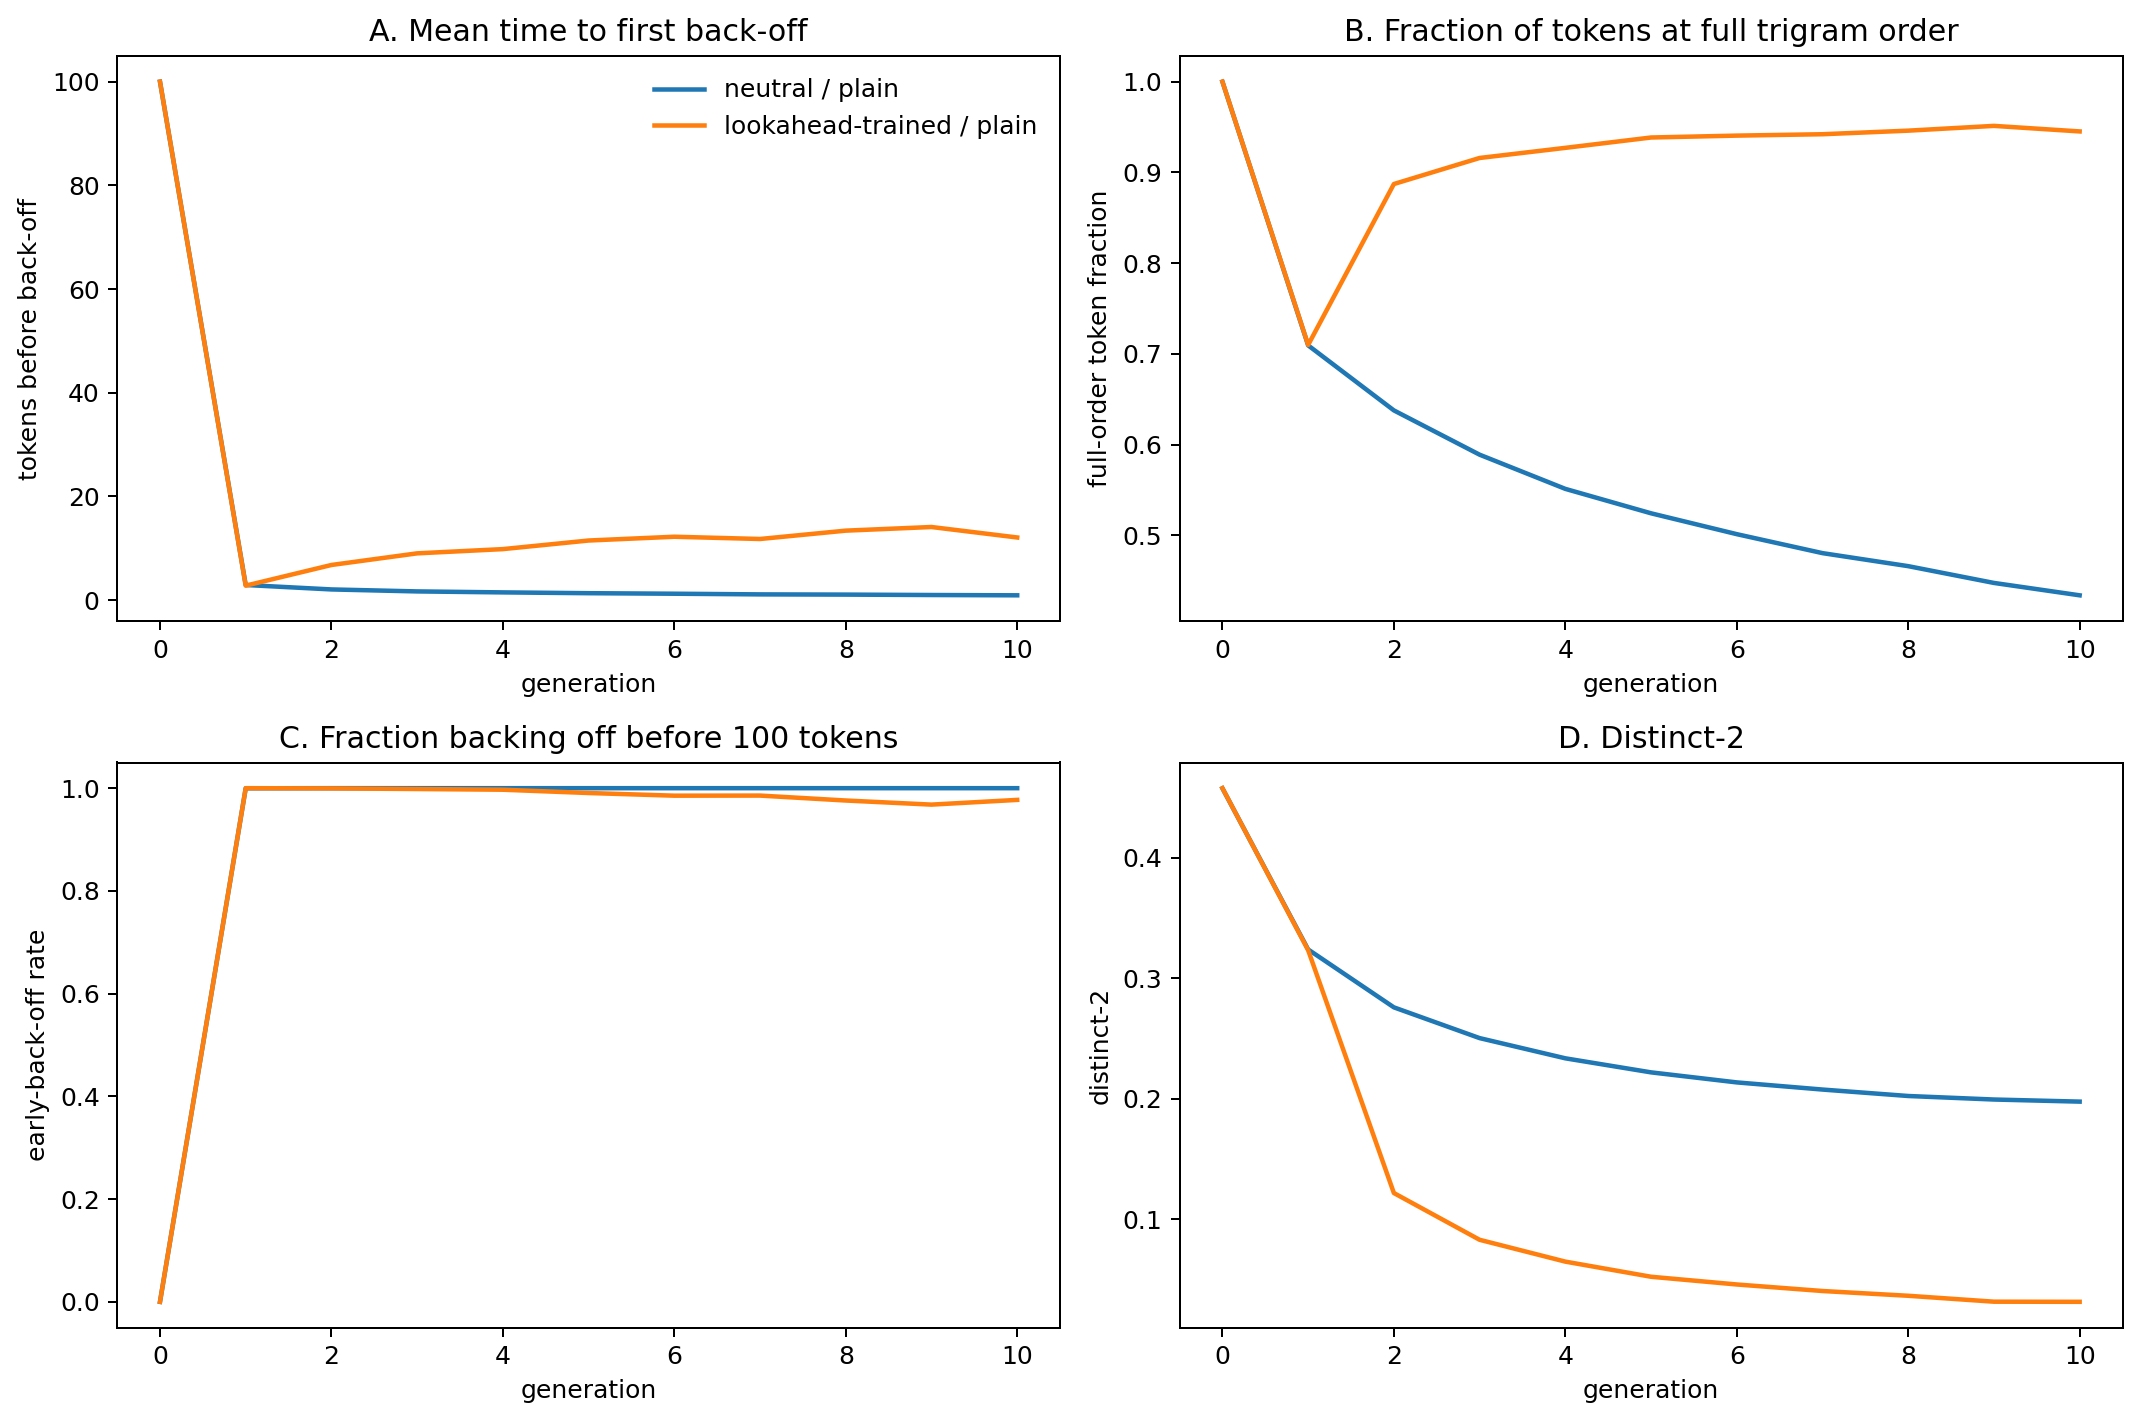

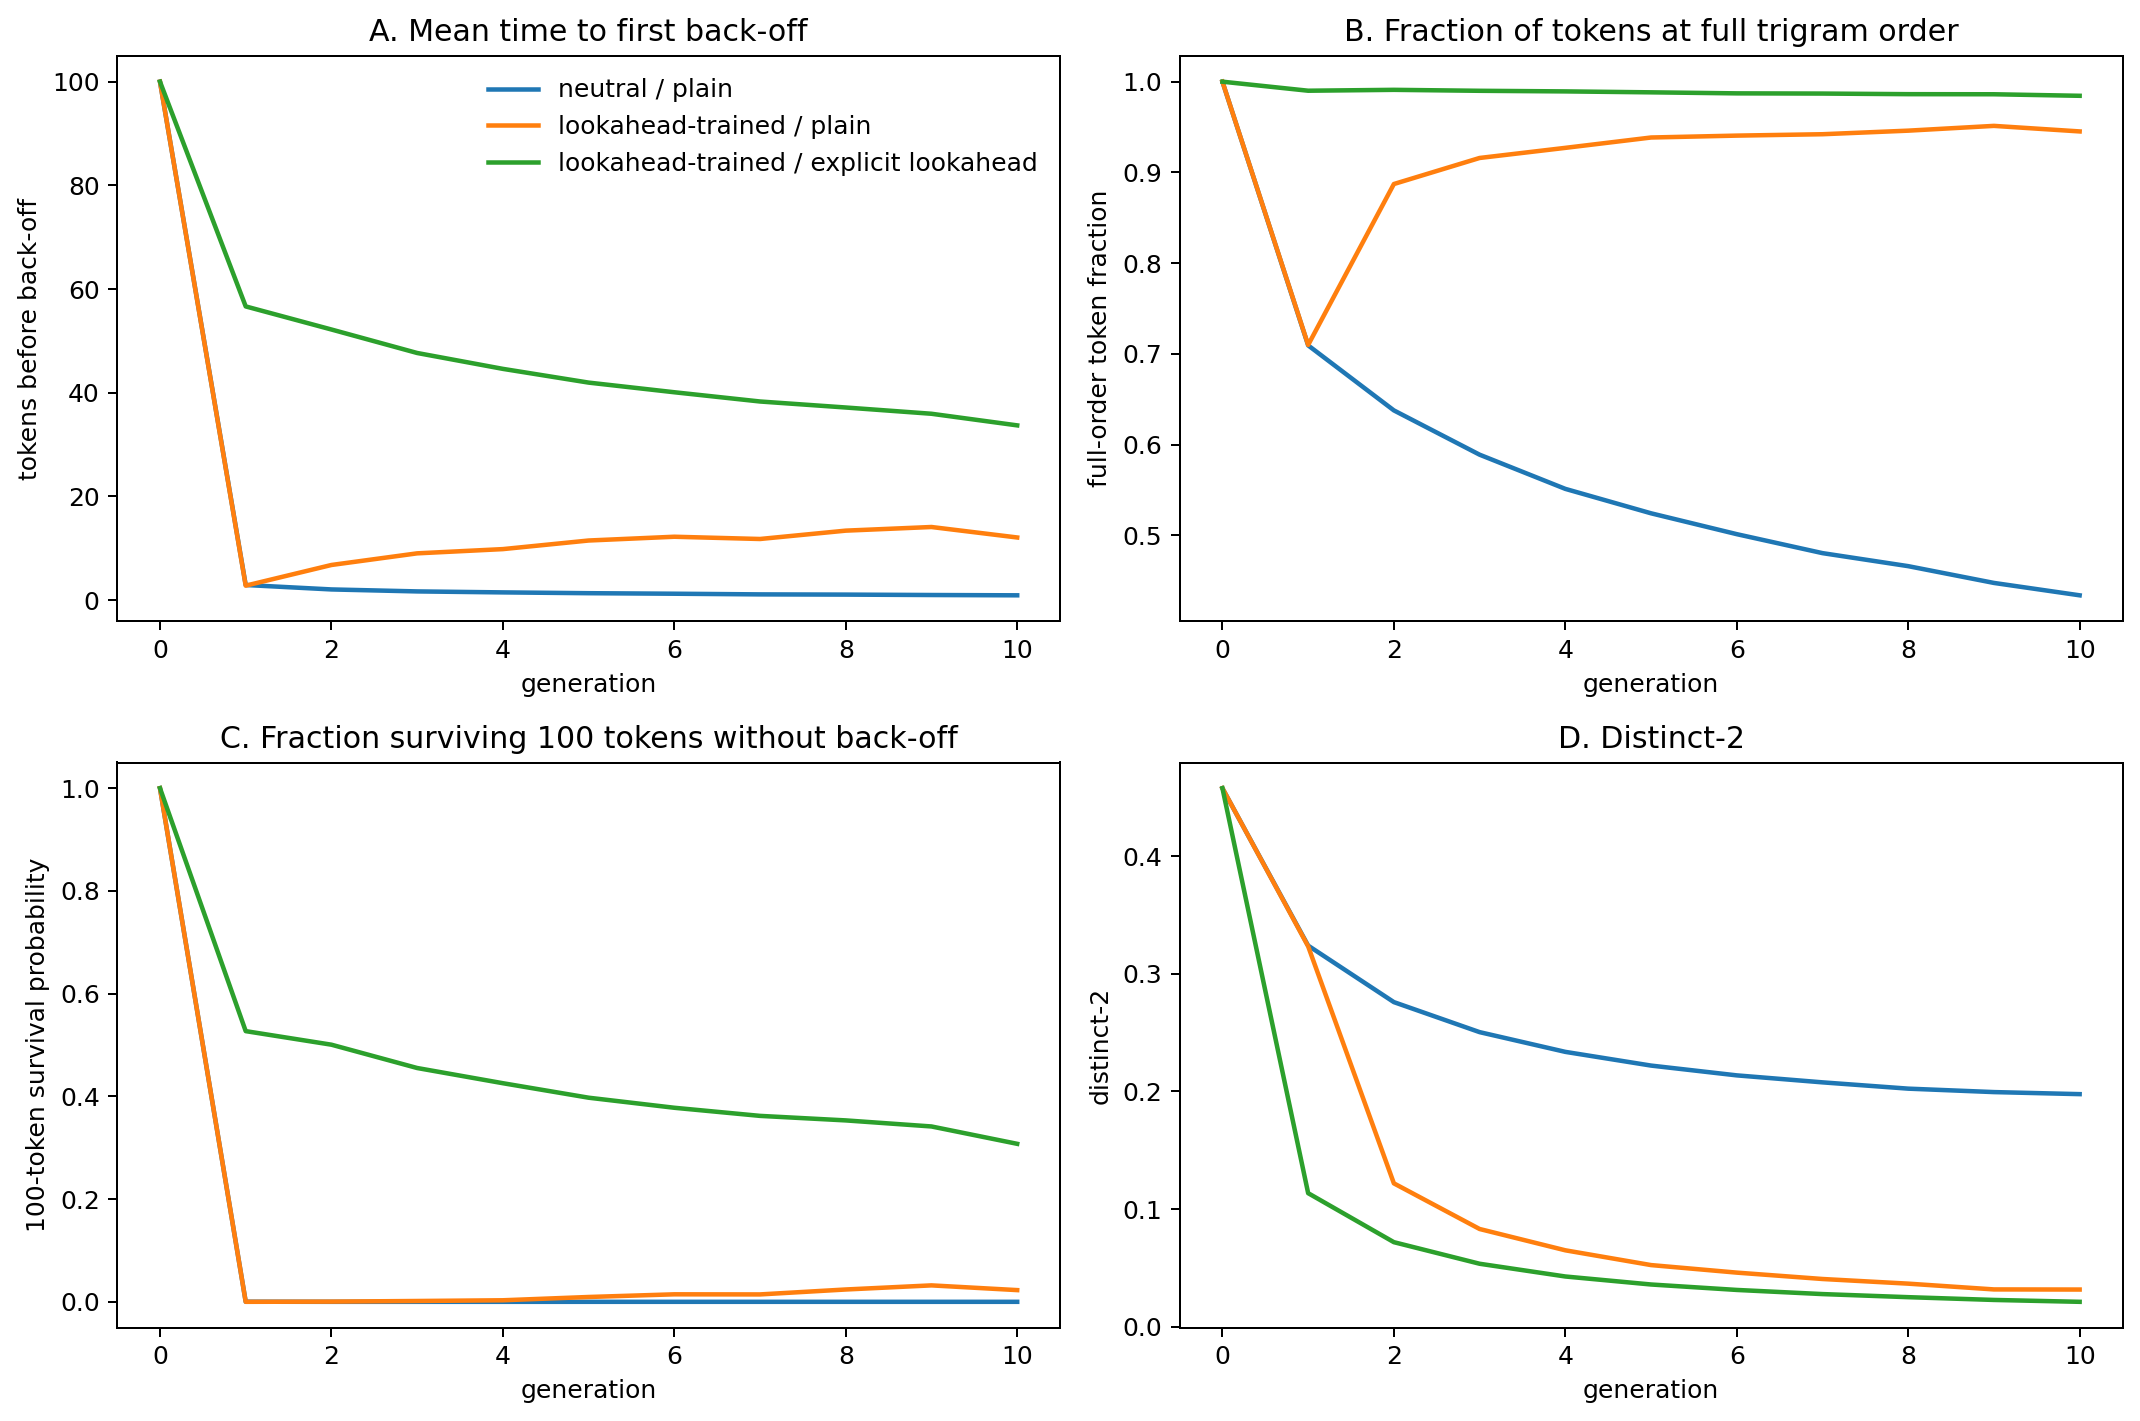

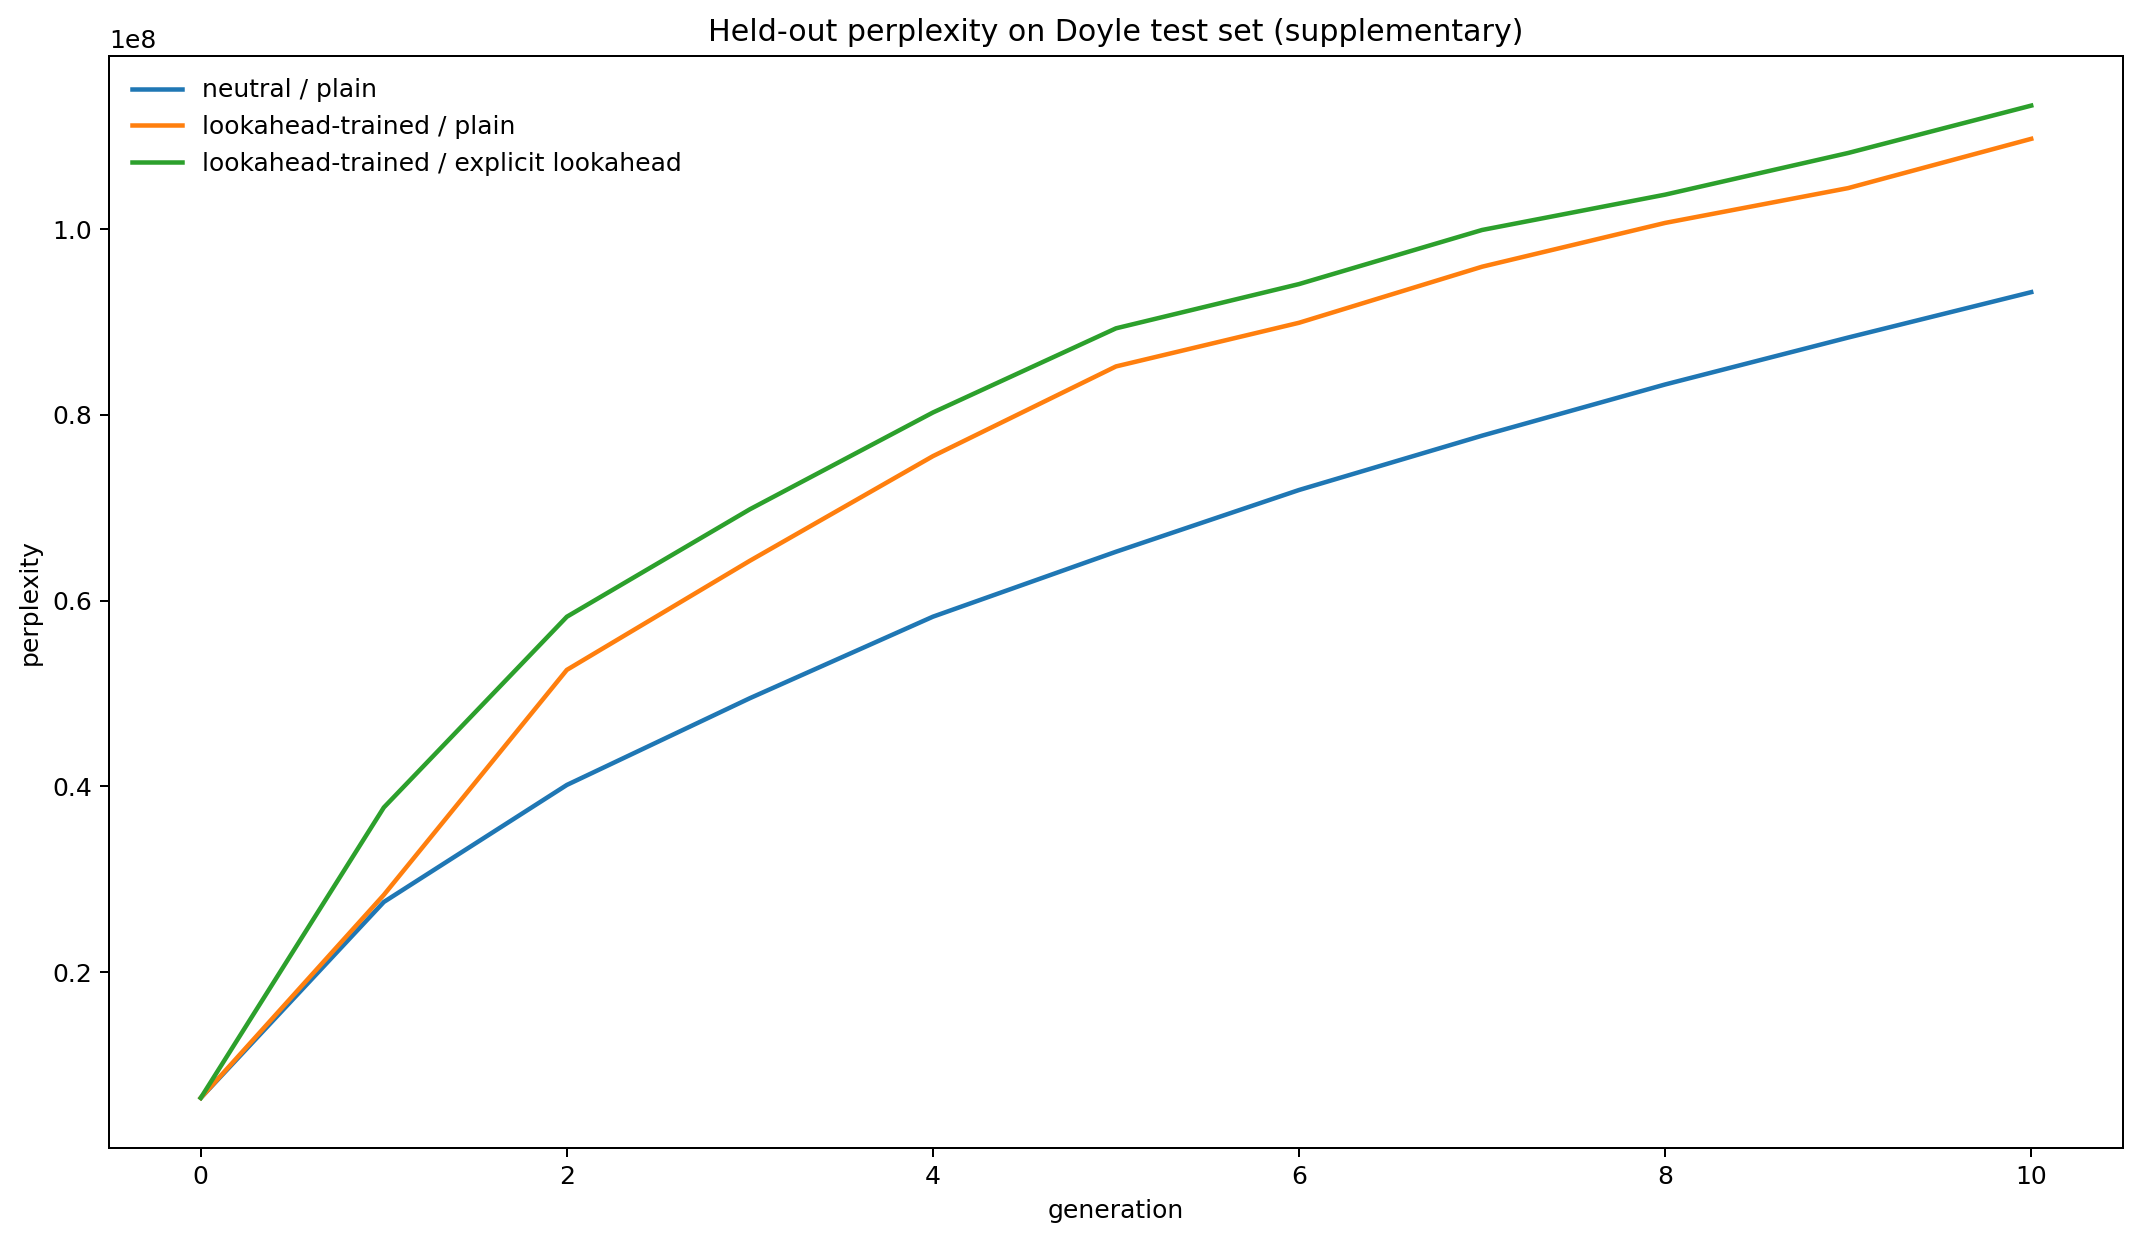

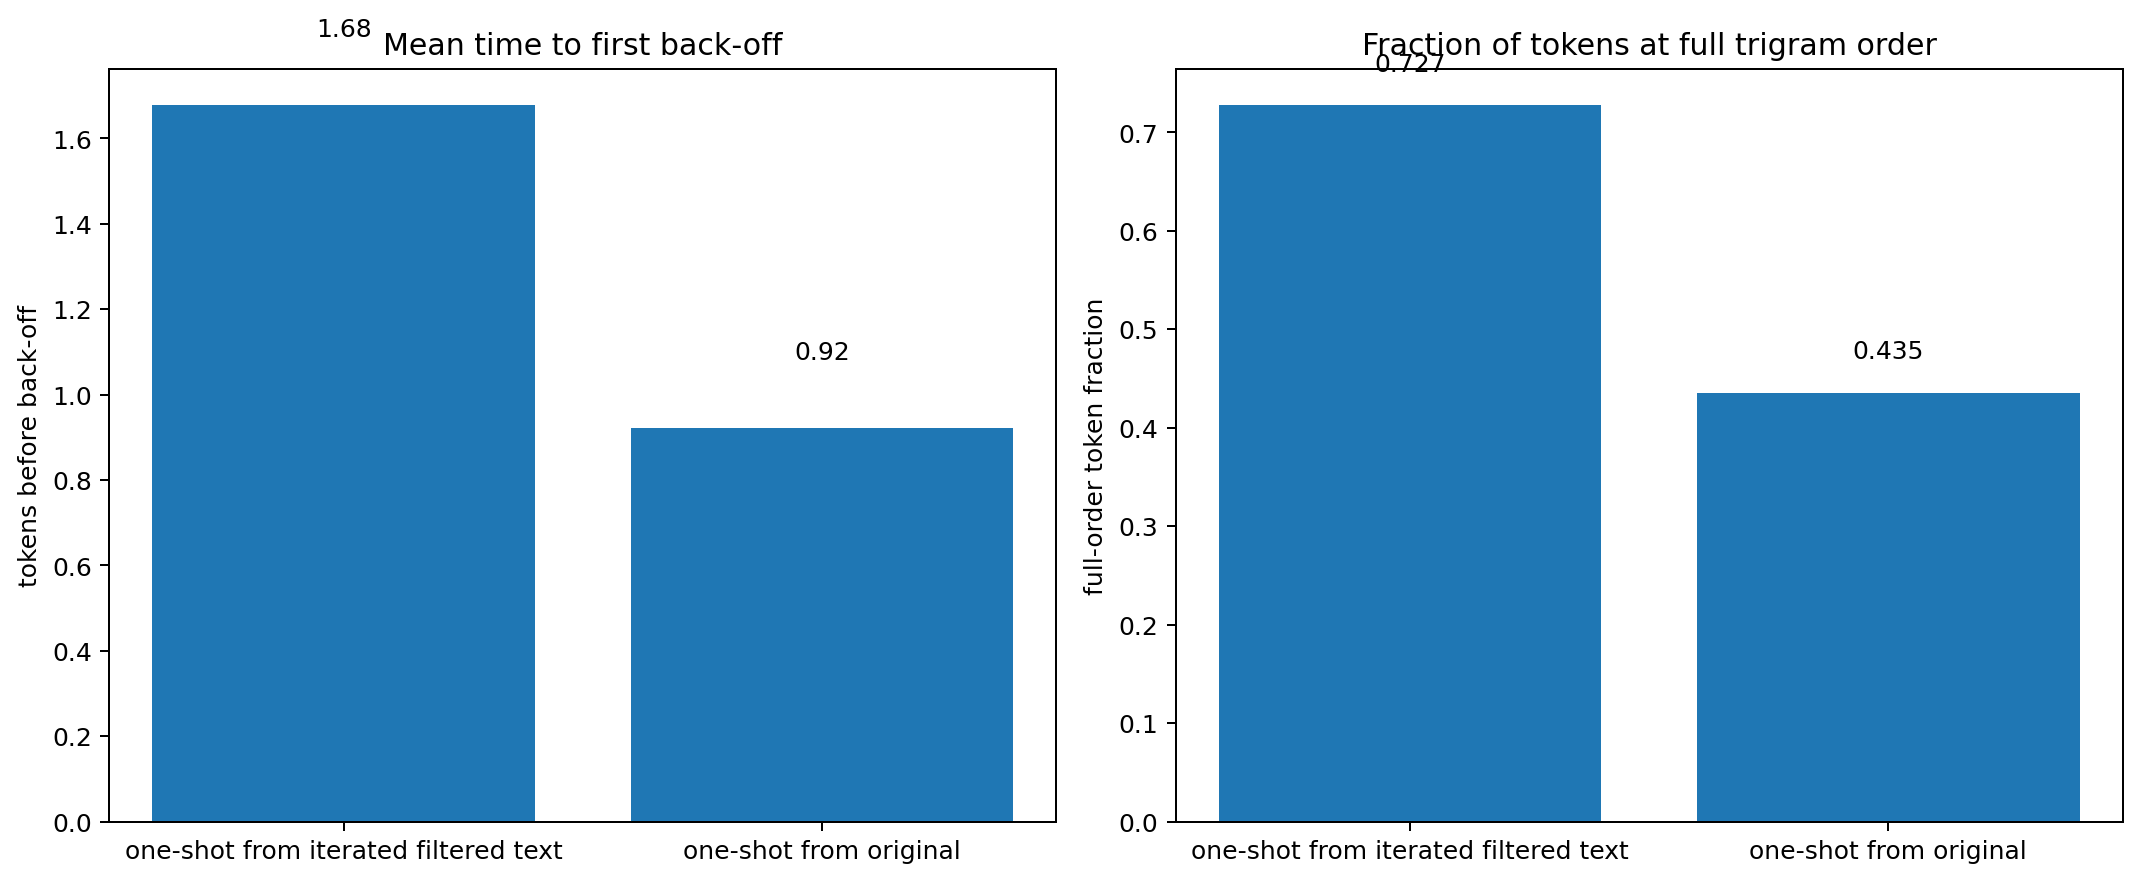

In [5]:
from IPython.display import Image, display

for key in ["main_figure", "explicit_figure", "perplexity_figure", "bars_figure"]:
    pdf_path = Path(outputs[key])
    png_path = pdf_path.with_suffix(".png")
    if png_path.exists():
        display(Image(filename=str(png_path)))
    else:
        print(pdf_path)
